In [10]:
import json

from scipy import constants as const

import drjit as dr
import matplotlib.pyplot as plt
import numpy as np

import mitsuba as mi

# colocar el valor de spectral
mi.set_variant("cuda_ad_spectral")

from mitsuba import ScalarTransform4f as T


In [11]:
def blackbody_radiance_nm(wavelengths_nm, temperature):
    """
    Compute spectral radiance B(λ, T) of a black body
    using scipy constants.

    Args:
        wavelengths_nm: array-like of wavelengths in nanometers (nm).
        temperature:    temperature in Kelvin (K).

    Returns:
        numpy array of spectral radiance in  μW/cm²/sr/μm (microflicks)
    """
    # Convert wavelengths to meters
    wavelengths_m = np.array(wavelengths_nm, dtype=float) * 1e-9

    # Planck's law for spectral radiance: from W/m²/sr/m
    exponent = (const.h * const.c) / (wavelengths_m * const.k * temperature)
    radiance = (2 * const.h * const.c**2) / (wavelengths_m**5) / (np.exp(exponent) - 1)

    # Convert radiance from W/m²/sr/m to μW/cm²/sr/μm
    radiance = radiance * 1e-4

    return radiance

In [12]:
result_path = "../output/static/result/"
static = "../output/static/"

In [13]:
with open(static + "config_scene.json", "r") as f:
    config = json.load(f)


In [14]:
wavelengths = np.array(config["wavelengths"])
num_wavelengths = len(wavelengths)
wavelength_min = np.min(wavelengths)
wavelength_max = np.max(wavelengths)

t_aire = config["air"]['temperature']
blackbody_air = blackbody_radiance_nm(wavelengths, t_aire)  # µW/cm²/sr/µm

In [15]:
depth = np.load(result_path + "depth.npy")
thermal = np.load(result_path + "thermal.npy")
b_air = np.load(result_path + "blackbody_air.npy")
t_b_air = np.load(result_path + "transmittance_blackbody_air.npy")
contribution_air = np.load(result_path + "contribution_blackbody_air.npy")
tmap = np.load(result_path + "temperature_map.npy")

In [16]:
import plotly.express as px

# Imagen interactiva con hover para ver coordenadas y valores RGB
fig = px.imshow(tmap, origin='upper', title="Imagen RGB (pase el mouse para ver píxeles)")
fig.update_traces(
    customdata=tmap,
)
fig.update_xaxes(title="x (columna)")
fig.update_yaxes(title="y (fila)")
fig.show()

In [20]:
xs = [110, 110,110]
ys = [133, 150, 250]

In [ ]:
# objeto 1
# x, y = 160, 200
# firma = np.loadtxt(static + "meshes/Cube_002_1.txt", delimiter='\t')
# x, y = 90, 105
# firma = np.loadtxt(static + "meshes/Kugel_4.txt", delimiter='\t')
xs = [110, 110,110]
ys = [133, 150, 250]
firma = np.loadtxt(static + "meshes/Cube_002_1.txt", delimiter='\t')
firma[:,1] = firma[:,1]/100
emisividad = 1-firma[:,1]
reflectancia = firma[:,1]

plt.figure(figsize=(6, 6))
plt.axvline(x=wavelength_min/1000, color='red', linestyle='--', alpha=0.5)
plt.axvline(x=wavelength_max/1000, color='red', linestyle='--', alpha=0.5)

plt.plot(firma[:,0], emisividad, color='blue', label='Emisividad')
plt.plot(firma[:,0], reflectancia, color='orange', label='Reflectancia')
plt.xlabel('Longitud de onda (µm)')
plt.ylabel('Emisividad / Reflectancia')
plt.title('Emisividad y Reflectancia del Objeto')
plt.grid()
plt.legend()
plt.show()

FileNotFoundError: ../output/static/meshes/Cube_002_1.txt not found.

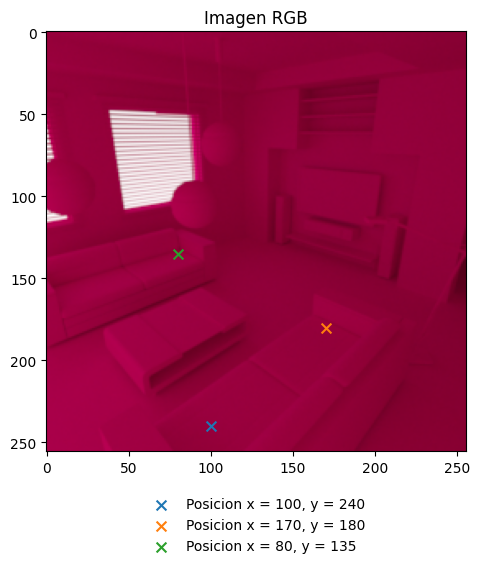

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(rgb)
for x, y in zip(xs, ys):
    plt.scatter(x, y, s=50, marker='x', label=f'Posicion x = {x}, y = {y}')
plt.title("Imagen RGB")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.subplots_adjust(bottom=0.18)
plt.show()

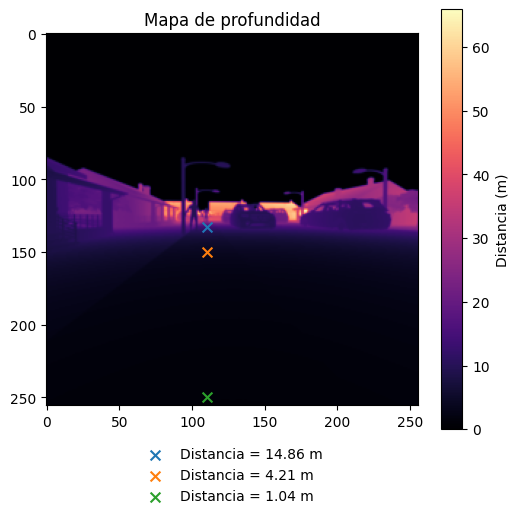

In [21]:
distancias = []

plt.figure(figsize=(6, 6))
plt.imshow(depth, cmap='magma')
plt.colorbar(label='Distancia (m)')
for x, y in zip(xs, ys):
    distancias.append(depth[y,x])
    plt.scatter(x, y, s=50, marker='x', label=f'Distancia = {depth[y,x]:.2f} m')
plt.title("Mapa de profundidad")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.subplots_adjust(bottom=0.18)
plt.show()

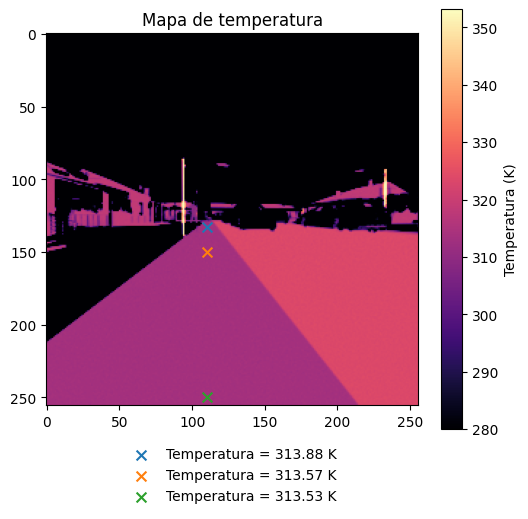

In [22]:
temperaturas = []

plt.figure(figsize=(6, 6))
plt.imshow(tmap, cmap='magma', vmin=t_aire)
plt.colorbar(label='Temperatura (K)')
for x, y in zip(xs, ys):
    temperaturas.append(tmap[y,x])
    plt.scatter(x, y, s=50, marker='x', label=f'Temperatura = {tmap[y,x]:.2f} K')
plt.title("Mapa de temperatura")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.subplots_adjust(bottom=0.18)
plt.show()

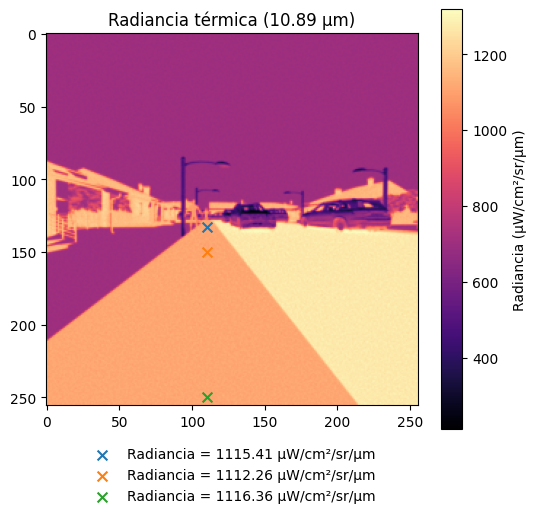

In [23]:
banda = 4
radiancias = []

plt.figure(figsize=(6, 6))
plt.imshow(thermal[:, :, banda], cmap='magma')
plt.colorbar(label='Radiancia (μW/cm²/sr/μm)')
for x, y in zip(xs, ys):
    radiancias.append(thermal[y,x,:])
    plt.scatter(x, y, s=50, marker='x', label=f'Radiancia = {thermal[y,x,banda]:.2f} μW/cm²/sr/μm')
plt.title(f"Radiancia térmica ({wavelengths[banda]/1000:.2f} µm)")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.subplots_adjust(bottom=0.18)
plt.show()

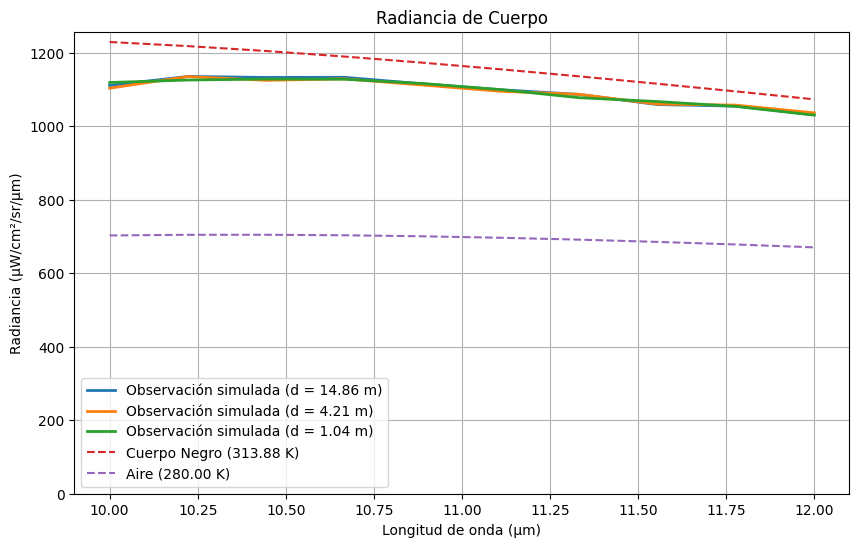

In [25]:
blackbody_air = blackbody_radiance_nm(wavelengths, t_aire)
blackbodys = [blackbody_radiance_nm(wavelengths, temperatura) for temperatura in temperaturas]
#transmitancias = [np.exp(-atenuacion_air*distancia) for distancia in distancias]

plt.figure(figsize=(10, 6))
for i, distancia in enumerate(distancias):
    plt.plot(wavelengths/1000, radiancias[i], label=f'Observación simulada (d = {distancia:.2f} m)', linewidth=2)
plt.plot(wavelengths/1000, blackbodys[0 ], label=f'Cuerpo Negro ({temperaturas[0]:.2f} K)', linestyle='--')
plt.plot(wavelengths/1000, blackbody_air, label=f'Aire ({t_aire:.2f} K)', linestyle='--')
plt.xlabel('Longitud de onda (µm)')
plt.ylabel('Radiancia (µW/cm²/sr/µm)')
plt.title('Radiancia de Cuerpo')
plt.legend()
plt.ylim(0, None)
plt.grid()